# Settings

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp
import scipy as sc
from matplotlib import pyplot
from numpy import mean, std
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad
import time
import astropy.cosmology as ac
import astropy.constants as cst
from scipy.misc import derivative
import csv
from sklearn.linear_model import LinearRegression
import statistics as stat
from astropy.io import fits

In [7]:
#graph parameters
police=15

In [8]:
# define cosmological parameters
H0=73
Mb=-19.3
c=float(np.array(cst.c.to('km/s')))


#for flat LCDM, according to Planck 2018 (TT,TE,EE+lowE+lensing)
Om0_fLCDM = 0.3153
Ode0_fLCDM = 1-Om0_fLCDM

#for LCDM
Om0_kLCDM, Ode0_kLCDM = 0.3153, 0.6
Ok0_kLCDM = 1-Om0_kLCDM-Ode0_kLCDM

#for flat wCDM
Om0_fwCDM, w0_fwCDM = 0.3153, -1.029

#for k-wCDM
Om0_kwCDM, Ode0_kwCDM, w0_kwCDM =  0.3153, 0.6, -1.029

#for flat CPL
Om0_fCPL, w0_fCPL, wa_fCPL = 0.3153, -1.029, 0.21

#for CPL
Om0_kCPL, Ode0_kCPL, w0_kCPL, wa_kCPL = 0.3153, 0.6, -1.029, 0.21

#for PEDE
Om0_PEDE, Ode0_PEDE = 0.3153, 0.6
Ok0_PEDE=1-Om0_PEDE-Ode0_PEDE


In [9]:
# astropy cosmo

#LCDM
cosmo_fLCDM = ac.FlatLambdaCDM(H0=H0,Om0=Om0_fLCDM)
cosmo_kLCDM = ac.LambdaCDM(H0=H0,Om0=Om0_kLCDM,Ode0=Ode0_kLCDM)

#wCDM
cosmo_fwCDM = ac.FlatwCDM(H0=H0,Om0=Om0_fwCDM,w0=w0_fwCDM)
cosmo_kwCDM = ac.wCDM(H0=H0,Om0=Om0_kwCDM,Ode0=Ode0_kwCDM,w0=w0_kwCDM)

#CPL
cosmo_fCPL= ac.Flatw0waCDM(H0=H0, Om0=Om0_fCPL, w0=w0_fCPL, wa=wa_fCPL)
cosmo_kCPL= ac.w0waCDM(H0=H0, Om0=Om0_kCPL, Ode0=Ode0_kCPL, w0=w0_kCPL, wa=wa_kCPL)

# LSST data

In [10]:
# lsst data

lsst = pd.read_table('lsst_snIa_data.csv',sep=',')
z_lsst=np.array(lsst.zHEL)
mu_lsst=np.array(lsst.MU)
dist_lsst=lsst.N

# statistical error
sigma_stat=lsst.MUERR
rho = 0
std_matrix =  np.diag(sigma_stat)
corr_matrix = np.full((len(sigma_stat),len(sigma_stat)),rho)
np.fill_diagonal(corr_matrix,1.0)
Cov_stat = std_matrix @ corr_matrix @ std_matrix

# systematic error
Cov_sys=np.array(pd.read_table('covsys_lsst.csv',sep=',')).reshape((len(z_lsst),len(z_lsst))) 

# total covariance matrix
Cov_tot= Cov_sys + Cov_stat
Cov_inv_lsst=np.linalg.inv(Cov_tot)

# define bin edges
edges_mid = 0.5 * (z_lsst[1:] + z_lsst[:-1])
# first and last edges
first_edge = z_lsst[0] - (edges_mid[0] - z_lsst[0])
last_edge  = z_lsst[-1] + (z_lsst[-1] - edges_mid[-1])

# combine
z_edges = np.concatenate([[first_edge], edges_mid, [last_edge]])

In [11]:
lsst.columns

Index(['ROW', 'zCMB', 'zHEL', 'MU', 'MUERR', 'MUERR_SYS', 'N'], dtype='object')

Text(0, 0.5, '# SNIa')

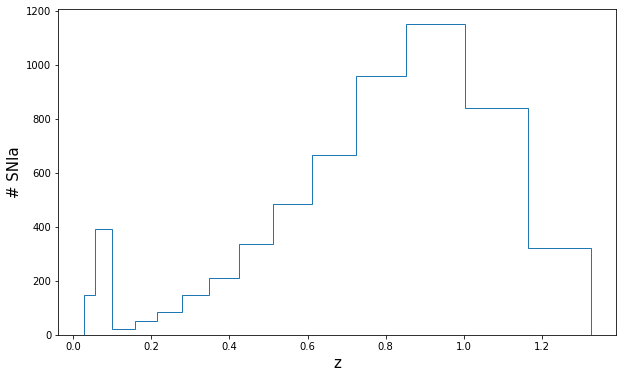

In [12]:
plt.figure(figsize=(10,6))
plt.stairs(dist_lsst,z_edges)
plt.xlabel('z',fontsize=police)
plt.ylabel('# SNIa',fontsize=police)

# LSST mock data

In [13]:
# gaussian noise
np.random.seed(42)
noise_lsst = np.random.multivariate_normal(
    mean=np.zeros(len(z_lsst)),
    cov=Cov_tot
)

In [14]:
# PEDE cosmology
def omega_DE_tilde(z,Ode0):
    "takes a 1D-array of z and Omega_lambda0 in argument, return a 1D-array omega_lambda(z)"
    return Ode0*(1-np.tanh(np.log10(1+z)))

def integrand(z,Om0,Ode0):
    "takes a 1D-array of z and omega_m in argument, return a 1D-array of 1/H(z)"
    Ok0=1-Om0-Ode0
    return 1/np.sqrt(Om0*(1+z)**3+omega_DE_tilde(z,Ode0)+Ok0*(1+z)**2)

def mu_th(z,Om0,Ode0):
    "takes a 1D-array of z and omega_m in argument, return a 1D-array of mu(z)"
    I = quad(integrand, 0, z, (Om0,Ode0))[0]
    dl=I*c*(1+z)/H0
    return 5*np.log10(dl)+25

cosmo_PEDE=np.vectorize(mu_th)

In [15]:
#compute mb(z_lsst) for the different cosmologies, add noise
mb_fLCDM=np.array(cosmo_fLCDM.distmod(z_lsst)) + Mb + noise_lsst
mb_kLCDM=np.array(cosmo_kLCDM.distmod(z_lsst)) + Mb + noise_lsst

mb_fwCDM=np.array(cosmo_fwCDM.distmod(z_lsst)) + Mb + noise_lsst
mb_kwCDM=np.array(cosmo_kwCDM.distmod(z_lsst)) + Mb + noise_lsst

mb_fCPL=np.array(cosmo_fCPL.distmod(z_lsst)) + Mb + noise_lsst
mb_kCPL=np.array(cosmo_kCPL.distmod(z_lsst)) + Mb + noise_lsst

mb_kPEDE=np.array(cosmo_PEDE(z_lsst,Om0_PEDE,Ode0_PEDE)) + Mb + noise_lsst

In [16]:
#save mock data
np.savez('LSST_fLCDM.npz',z=z_lsst,mb=mb_fLCDM)
np.savez('LSST_kLCDM.npz',z=z_lsst,mb=mb_kLCDM)

np.savez('LSST_fwCDM.npz',z=z_lsst,mb=mb_fwCDM)
np.savez('LSST_kwCDM.npz',z=z_lsst,mb=mb_kwCDM)

np.savez('LSST_fCPL.npz',z=z_lsst,mb=mb_fCPL)
np.savez('LSST_kCPL.npz',z=z_lsst,mb=mb_kCPL)

np.savez('LSST_kPEDE.npz',z=z_lsst,mb=mb_kCPL)
